# Types of Learning

This notebook contrasts the main learning paradigms side by side: supervised classification, supervised regression, unsupervised clustering and unsupervised dimensionality reduction.

## Import Required Libraries

Import the generators, estimators and plotting tools used for each paradigm.

In [1]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import (make_classification, make_regression,
                              make_blobs, load_digits)
from sklearn.linear_model import (LogisticRegression,
                                  LinearRegression)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Define the course colour palette.
colors = ["#179E86", "#2580B7", "#9EBE5B", "#C03B26", "#44546A"]
np.random.seed(42)

## Supervised Classification

A labelled two-class problem where logistic regression learns a decision boundary between the classes.

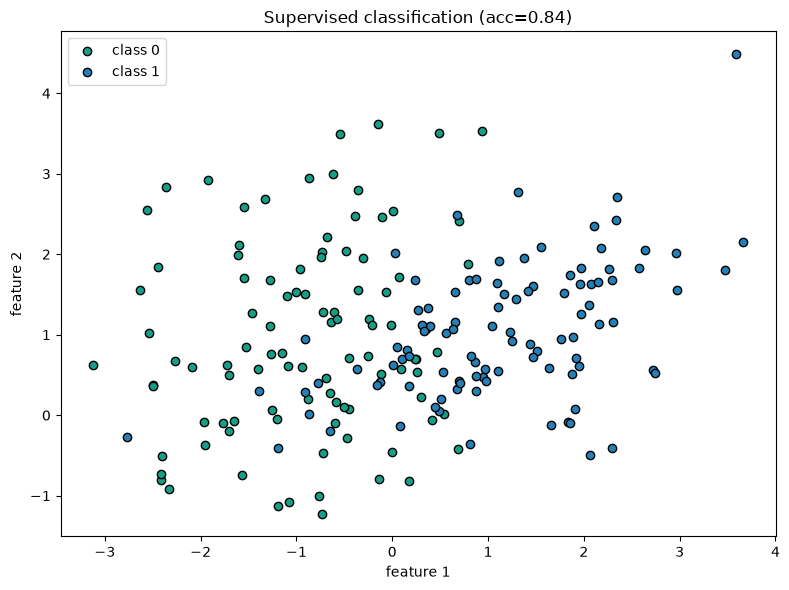

In [2]:
# Generate a two-class classification problem and fit a model.
Xc, yc = make_classification(
    n_samples=200, n_features=2, n_redundant=0, n_informative=2,
    n_clusters_per_class=1, random_state=42)
clf = LogisticRegression().fit(Xc, yc)

# Plot the labelled points coloured by class.
plt.figure(figsize=(8, 6))
for k in np.unique(yc):
    mask = yc == k
    plt.scatter(Xc[mask, 0], Xc[mask, 1], color=colors[k],
                label=f"class {k}", edgecolor="k")
plt.title(f"Supervised classification (acc="
          f"{clf.score(Xc, yc):.2f})")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.tight_layout()
plt.show()

## Supervised Regression

A labelled continuous target where linear regression fits a line through the noisy data.

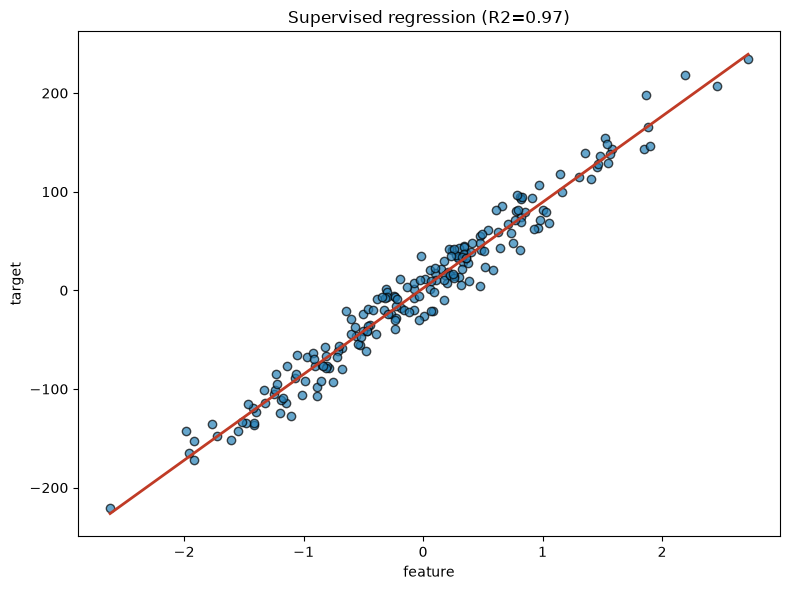

In [3]:
# Generate a regression problem and fit a linear model.
Xr, yr = make_regression(
    n_samples=200, n_features=1, noise=15.0, random_state=42)
reg = LinearRegression().fit(Xr, yr)

# Plot the data and the fitted regression line.
order = np.argsort(Xr[:, 0])
plt.figure(figsize=(8, 6))
plt.scatter(Xr, yr, color=colors[1], edgecolor="k", alpha=0.7)
plt.plot(Xr[order], reg.predict(Xr)[order], color=colors[3],
         linewidth=2)
plt.title(f"Supervised regression (R2={reg.score(Xr, yr):.2f})")
plt.xlabel("feature")
plt.ylabel("target")
plt.tight_layout()
plt.show()

## Unsupervised Clustering

Without labels, k-means groups the points into clusters and marks the learned centroids.

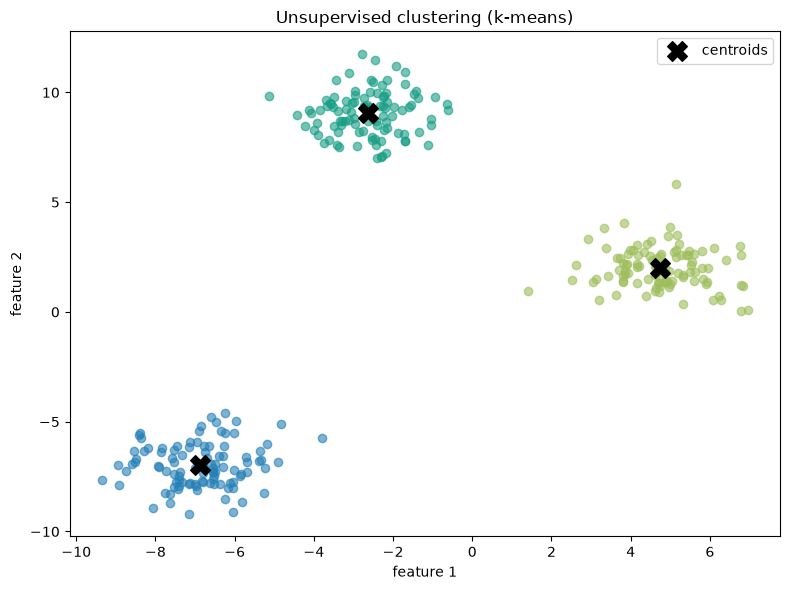

In [4]:
# Generate blobs and cluster them without using labels.
Xb, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0,
                   random_state=42)
km = KMeans(n_clusters=3, n_init=10, random_state=42).fit(Xb)

# Plot the points coloured by the discovered cluster.
plt.figure(figsize=(8, 6))
for k in range(3):
    mask = km.labels_ == k
    plt.scatter(Xb[mask, 0], Xb[mask, 1], color=colors[k],
                alpha=0.6)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            color="k", marker="X", s=200, label="centroids")
plt.title("Unsupervised clustering (k-means)")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.legend()
plt.tight_layout()
plt.show()

## Unsupervised Dimensionality Reduction

PCA projects the 64-dimensional digit images onto two components so the structure becomes visible in a plane.

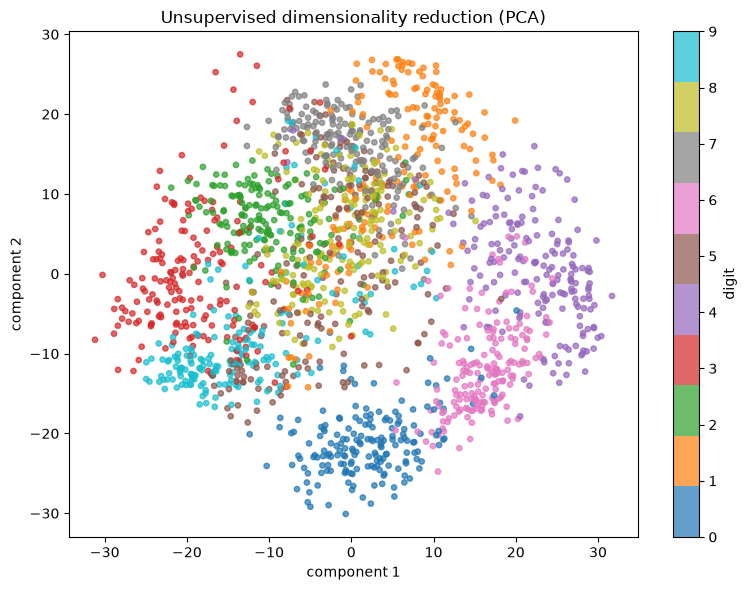

In [5]:
# Reduce the digits dataset to two principal components.
digits = load_digits()
Xd = PCA(n_components=2, random_state=42).fit_transform(
    digits.data)

# Plot the projection coloured by the true digit label.
plt.figure(figsize=(8, 6))
sc = plt.scatter(Xd[:, 0], Xd[:, 1], c=digits.target,
                 cmap="tab10", alpha=0.7, s=15)
plt.title("Unsupervised dimensionality reduction (PCA)")
plt.xlabel("component 1")
plt.ylabel("component 2")
plt.colorbar(sc, label="digit")
plt.tight_layout()
plt.show()

## Summary

- **Supervised classification**: predicts a discrete label from labelled data.
- **Supervised regression**: predicts a continuous value from labelled data.
- **Unsupervised clustering**: groups instances without labels.
- **Unsupervised dimensionality reduction**: compresses features while preserving structure.